# 03 — Parameter Analysis & Visualisation


In [15]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az

from rsa_models import (
    UTTERANCES, STATES, RELATIONS, N_utt, N_sta, N_rel,
    L0, state_vals, U_epi, U_soc_base,
    build_rsa_c, build_rsa_f,
    flat_speaker_logit, load_speaker_counts, load_speaker_logit_avg,
    flat_listener_logit, load_listener_counts, load_listener_logit_avg,
    save_trace, load_trace,
)

print('imports OK')

imports OK


In [16]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
LLM_MODELS  = ["qwen3-8b_zero", "llama3-8b_zero"]   # 돌릴 LLM 목록
MCMC_DRAWS  = 4000
MCMC_TUNE   = 4000
MCMC_CHAINS = 4
SKIP_IF_EXISTS = False   # 이미 저장된 trace가 있으면 건너뜀
# ─────────────────────────────────────────────────────────────────────────────

In [17]:
# ── KDE mode (MAP proxy) — Human MAP 비교 ───────────────────
from scipy.stats import gaussian_kde as _scipy_kde

def _kde_mode(flat, n_grid=2000):
    """posterior samples → KDE mode (MAP proxy)"""
    lo, hi = float(flat.min()), float(flat.max())
    if lo == hi: return lo
    grid = np.linspace(lo, hi, n_grid)
    return float(grid[_scipy_kde(flat, bw_method='scott')(grid).argmax()])

def posterior_map(tr, param, rel_idx=None):
    """관계별(rel_idx 지정) 또는 global(None) 파라미터의 MAP 반환"""
    s = tr.posterior[param].values
    flat = s[:, :, rel_idx].flatten() if (s.ndim == 3 and rel_idx is not None) else s.flatten()
    return _kde_mode(flat)

# ── 파라미터 요약 테이블 — pRRSAc φ (per relationship, Model A=choice, C=logit) ──
HUMAN_PHI_LI = {'enge Freundin': 0.45, 'entfernte Kollegin': 0.31,
                'lockere Chefin': 0.371, 'gefürchtete Chefin': 0.22}
HUMAN_PHI_SP = {'enge Freundin': 0.45, 'entfernte Kollegin': 0.31,
                'lockere Chefin': 0.37, 'gefürchtete Chefin': 0.22}

rows = []
for rel in RELATIONS:
    row = {'Relationship': rel,
           'Human (LI)': HUMAN_PHI_LI[rel],
           'Human (SP)': HUMAN_PHI_SP[rel]}
    for llm in LLM_MODELS:
        for role, model_id in [('listener', 'A'), ('listener', 'C'),
                                ('speaker',  'A'), ('speaker',  'C')]:
            tr = load_trace(llm, role, model_id)
            key = f'{llm[:6]} {role[:2].upper()} φ({model_id})'
            if tr is None or 'phi' not in tr.posterior:
                row[key] = float('nan')
            else:
                row[key] = round(posterior_map(tr, 'phi', RELATIONS.index(rel)), 3)
    rows.append(row)

df_phi = pd.DataFrame(rows)
print('\npRRSAc — φ (MAP posterior)')
print(df_phi.to_string(index=False))


pRRSAc — φ (MAP posterior)
      Relationship  Human (LI)  Human (SP)  qwen3- LI φ(A)  qwen3- LI φ(C)  qwen3- SP φ(A)  qwen3- SP φ(C)  llama3 LI φ(A)  llama3 LI φ(C)  llama3 SP φ(A)  llama3 SP φ(C)
     enge Freundin       0.450        0.45           0.149           0.223           0.531           0.901           0.872           0.880           0.947           0.843
entfernte Kollegin       0.310        0.31           0.137           0.223           0.549           0.885           0.950           0.972           0.931           0.796
    lockere Chefin       0.371        0.37           0.121           0.203           0.720           0.967           0.900           0.884           0.965           0.887
gefürchtete Chefin       0.220        0.22           0.151           0.233           0.751           0.935           0.770           0.811           0.976           0.897


In [18]:
# ── 파라미터 요약 테이블 — pRRSAf α (per relationship, Model B=choice, D=logit) ──
HUMAN_ALPHA = {'enge Freundin': 1.88, 'entfernte Kollegin': 2.9,
               'lockere Chefin': 1.97, 'gefürchtete Chefin': 4.63}

rows = []
for rel in RELATIONS:
    row = {'Relationship': rel,
           'Human (LI)': HUMAN_ALPHA[rel],
           'Human (SP)': HUMAN_ALPHA[rel]}
    for llm in LLM_MODELS:
        for role, model_id in [('listener', 'B'), ('listener', 'D'),
                                ('speaker',  'B'), ('speaker',  'D')]:
            tr = load_trace(llm, role, model_id)
            key = f'{llm[:6]} {role[:2].upper()} α({model_id})'
            if tr is None or 'alpha' not in tr.posterior:
                row[key] = float('nan')
            else:
                row[key] = round(posterior_map(tr, 'alpha', RELATIONS.index(rel)), 3)
    rows.append(row)

df_alpha = pd.DataFrame(rows)
print('\npRRSAf — α (MAP posterior)')
print(df_alpha.to_string(index=False))


pRRSAf — α (MAP posterior)
      Relationship  Human (LI)  Human (SP)  qwen3- LI α(B)  qwen3- LI α(D)  qwen3- SP α(B)  qwen3- SP α(D)  llama3 LI α(B)  llama3 LI α(D)  llama3 SP α(B)  llama3 SP α(D)
     enge Freundin        1.88        1.88           3.239           3.706           4.497           1.859           4.129           0.443           3.087           3.378
entfernte Kollegin        2.90        2.90           1.694           4.265           4.373           3.329           4.552           0.490           4.717           4.607
    lockere Chefin        1.97        1.97           3.591           4.403           2.943           0.475           2.950           0.443           1.809           2.428
gefürchtete Chefin        4.63        4.63           4.295           4.229           0.988           0.420           3.898           1.276           0.789           1.146


In [19]:
# ── Posterior MAP (KDE mode) + Mean + 95% HDI → CSV 저장 ─────────────────────
# Human reference는 MAP이므로 LLM도 MAP으로 비교해야 함
HDI_PROB = 0.95

from scipy.stats import gaussian_kde as _kde

def _kde_mode(flat, n_grid=2000):
    lo, hi = flat.min(), flat.max()
    if lo == hi: return float(lo)
    grid = np.linspace(lo, hi, n_grid)
    return float(grid[_kde(flat, bw_method='scott')(grid).argmax()])

def get_map_mean_hdi(tr, param, rel_idx):
    samples = tr.posterior[param].values
    flat = samples[:, :, rel_idx].flatten() if samples.ndim == 3 else samples.flatten()
    mean = float(flat.mean())
    mode = _kde_mode(flat)
    hdi  = az.hdi(flat, hdi_prob=HDI_PROB)
    return mode, mean, float(hdi[0]), float(hdi[1])

rows = []

# φ (pRRSAc: A=choice, C=logit)
for rel in RELATIONS:
    r_i = RELATIONS.index(rel)
    for llm in LLM_MODELS:
        short = 'Qwen3' if 'qwen' in llm else 'LLaMA3'
        for role, mid in [('listener','A'),('listener','C'),
                          ('speaker', 'A'),('speaker', 'C')]:
            tr = load_trace(llm, role, mid)
            row = {'param': 'phi', 'model': f'pRRSAc({mid})', 'llm': short,
                   'role': role, 'relationship': rel}
            if tr is None or 'phi' not in tr.posterior:
                row.update({'map': None, 'mean': None, 'hdi_low': None, 'hdi_high': None})
            else:
                mo, mn, lo, hi = get_map_mean_hdi(tr, 'phi', r_i)
                row.update({'map': round(mo,3), 'mean': round(mn,3),
                            'hdi_low': round(lo,3), 'hdi_high': round(hi,3)})
            rows.append(row)

# α (pRRSAf: B=choice, D=logit)
for rel in RELATIONS:
    r_i = RELATIONS.index(rel)
    for llm in LLM_MODELS:
        short = 'Qwen3' if 'qwen' in llm else 'LLaMA3'
        for role, mid in [('listener','B'),('listener','D'),
                          ('speaker', 'B'),('speaker', 'D')]:
            tr = load_trace(llm, role, mid)
            row = {'param': 'alpha', 'model': f'pRRSAf({mid})', 'llm': short,
                   'role': role, 'relationship': rel}
            if tr is None or 'alpha' not in tr.posterior:
                row.update({'map': None, 'mean': None, 'hdi_low': None, 'hdi_high': None})
            else:
                mo, mn, lo, hi = get_map_mean_hdi(tr, 'alpha', r_i)
                row.update({'map': round(mo,3), 'mean': round(mn,3),
                            'hdi_low': round(lo,3), 'hdi_high': round(hi,3)})
            rows.append(row)

df_hdi = pd.DataFrame(rows, columns=['param','model','llm','role','relationship',
                                      'map','mean','hdi_low','hdi_high'])
df_hdi.to_csv('results/param_hdi_95.csv', index=False)
print(f'저장 → results/param_hdi_95.csv ({len(df_hdi)} rows)')
print('\n컬럼: param, model, llm, role, relationship, map, mean, hdi_low, hdi_high')
print('(Human 비교는 map 컬럼 사용, HDI 표기는 [hdi_low, hdi_high])')

저장 → results/param_hdi_95.csv (64 rows)

컬럼: param, model, llm, role, relationship, map, mean, hdi_low, hdi_high
(Human 비교는 map 컬럼 사용, HDI 표기는 [hdi_low, hdi_high])


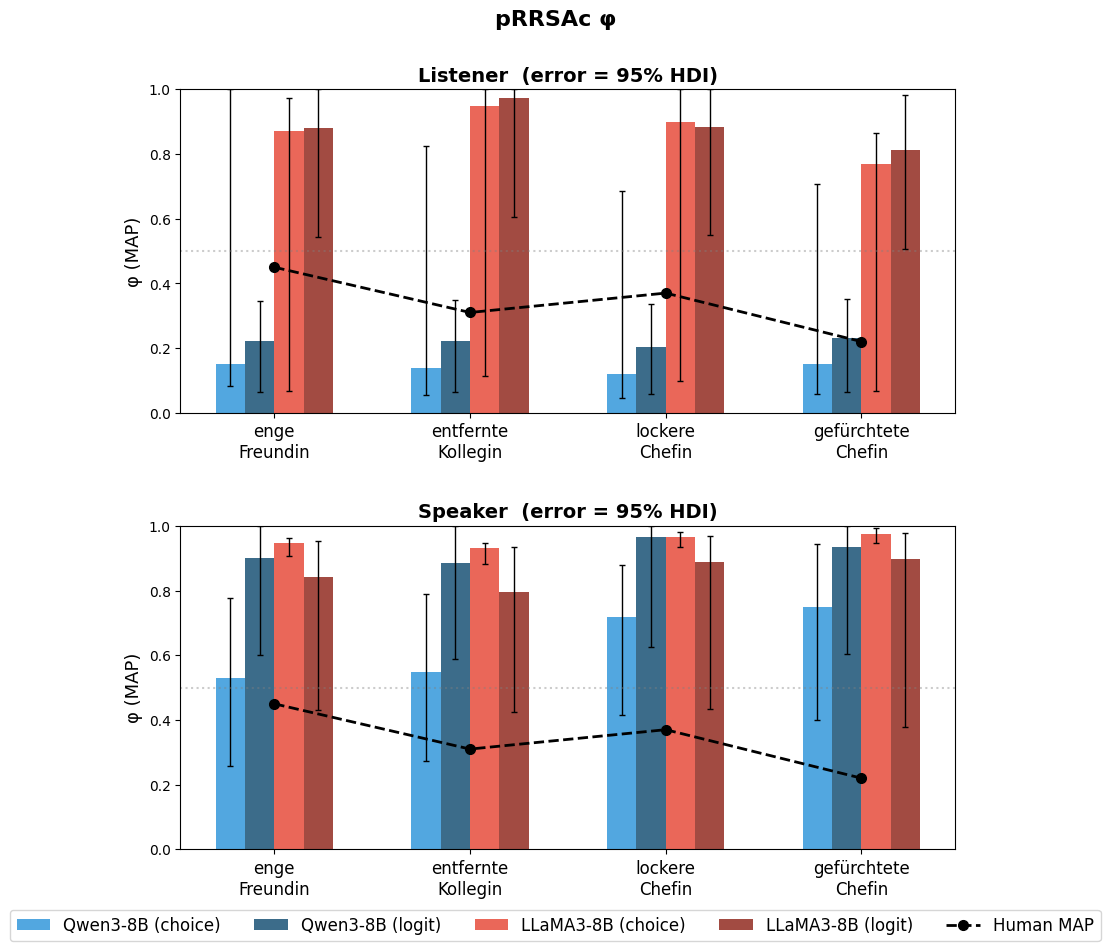

저장 → results/phi_comparison.png


In [20]:
# ── φ 비교 플롯 (pRRSAc) — choice(A) vs logit(C), Listener / Speaker 세로 병렬 ─
HUMAN_PHI = {'enge Freundin': 0.45, 'entfernte Kollegin': 0.31,
             'lockere Chefin': 0.37, 'gefürchtete Chefin': 0.22}

FONT_TITLE  = 14
FONT_LABEL  = 13
FONT_TICK   = 12
FONT_LEGEND = 12

labels = [r.replace(' ', '\n') for r in RELATIONS]
x = np.arange(N_rel)
width = 0.15

COLORS = {
    ('qwen3-8b_zero',  'choice'): '#3498db',
    ('qwen3-8b_zero',  'logit'):  '#1a5276',
    ('llama3-8b_zero', 'choice'): '#e74c3c',
    ('llama3-8b_zero', 'logit'):  '#922b21',
}
METHOD_MODEL = {'choice': 'A', 'logit': 'C'}
LLM_LABELS   = {'qwen3-8b_zero': 'Qwen3-8B', 'llama3-8b_zero': 'LLaMA3-8B'}

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fig.subplots_adjust(hspace=0.35, top=0.88, bottom=0.12)

legend_handles = []

for ax_i, role in enumerate(['listener', 'speaker']):
    ax = axes[ax_i]
    n_bars = len(LLM_MODELS) * 2
    offsets = np.linspace(-(n_bars-1)*width/2, (n_bars-1)*width/2, n_bars)
    bar_i = 0
    for llm in LLM_MODELS:
        for method, mid in METHOD_MODEL.items():
            tr = load_trace(llm, role, mid)
            if tr is None:
                bar_i += 1; continue
            samp = tr.posterior['phi'].values
            m = np.array([_kde_mode(samp[:, :, r_i].flatten()) for r_i in range(N_rel)])
            lo = np.array([az.hdi(samp[:,:,r_i].flatten(), hdi_prob=0.95)[0] for r_i in range(N_rel)])
            hi = np.array([az.hdi(samp[:,:,r_i].flatten(), hdi_prob=0.95)[1] for r_i in range(N_rel)])
            err = np.array([m - lo, hi - m])
            label = f'{LLM_LABELS[llm]} ({method})'
            bar = ax.bar(x + offsets[bar_i], m, width,
                         label=label, color=COLORS[(llm, method)], alpha=0.85)
            ax.errorbar(x + offsets[bar_i], m, err, fmt='none',
                        color='black', capsize=2, lw=1)
            if ax_i == 0:
                legend_handles.append(bar)
            bar_i += 1

    h_line, = ax.plot(x, [HUMAN_PHI[r] for r in RELATIONS],
                      'k--o', lw=2, ms=7, label='Human MAP', zorder=5)
    if ax_i == 0:
        legend_handles.append(h_line)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONT_TICK)
    ax.set_ylabel('\u03c6 (MAP)', fontsize=FONT_LABEL)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', ls=':', alpha=0.4)
    ax.set_title(f'{role.capitalize()}  (error = 95% HDI)',
                 fontsize=FONT_TITLE, fontweight='bold')

fig.suptitle('pRRSAc \u03c6', fontsize=16, fontweight='bold', y=0.96)
fig.legend(handles=legend_handles,
           loc='lower center', ncol=5,
           fontsize=FONT_LEGEND, frameon=True,
           bbox_to_anchor=(0.5, 0.02))
plt.savefig('results/phi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 → results/phi_comparison.png')


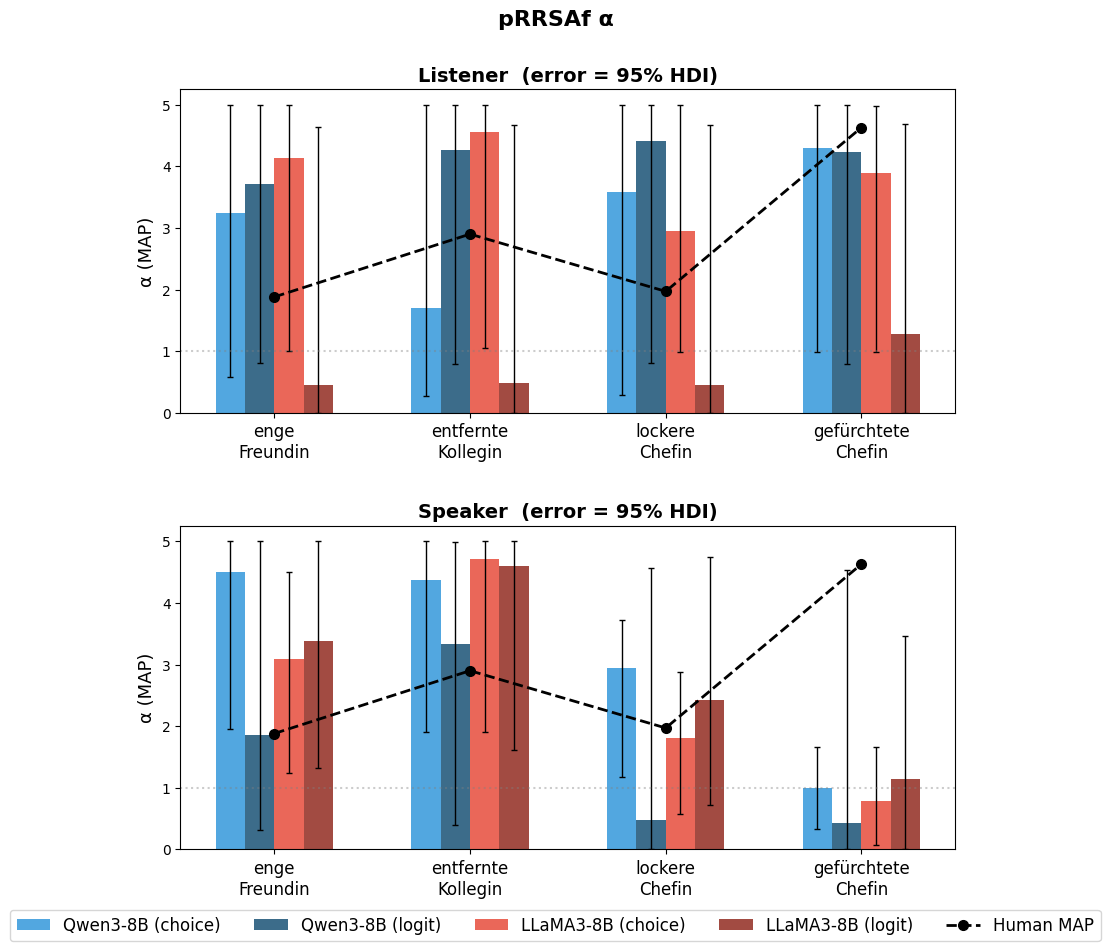

저장 → results/alpha_comparison.png


In [33]:
# ── α 비교 플롯 (pRRSAf) — choice(B) vs logit(D), Listener / Speaker 세로 병렬 ─
HUMAN_ALPHA = {'enge Freundin': 1.88, 'entfernte Kollegin': 2.9,
               'lockere Chefin': 1.97, 'gefürchtete Chefin': 4.63}

FONT_TITLE  = 14
FONT_LABEL  = 13
FONT_TICK   = 12
FONT_LEGEND = 12

labels = [r.replace(' ', '\n') for r in RELATIONS]
x = np.arange(N_rel)
width = 0.15

COLORS_A = {
    ('qwen3-8b_zero',  'choice'): '#3498db',
    ('qwen3-8b_zero',  'logit'):  '#1a5276',
    ('llama3-8b_zero', 'choice'): '#e74c3c',
    ('llama3-8b_zero', 'logit'):  '#922b21',
}
METHOD_MODEL_A = {'choice': 'B', 'logit': 'D'}
LLM_LABELS     = {'qwen3-8b_zero': 'Qwen3-8B', 'llama3-8b_zero': 'LLaMA3-8B'}

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fig.subplots_adjust(hspace=0.35, top=0.88, bottom=0.12)

legend_handles = []

for ax_i, role in enumerate(['listener', 'speaker']):
    ax = axes[ax_i]
    n_bars = len(LLM_MODELS) * 2
    offsets = np.linspace(-(n_bars-1)*width/2, (n_bars-1)*width/2, n_bars)
    bar_i = 0
    for llm in LLM_MODELS:
        for method, mid in METHOD_MODEL_A.items():
            tr = load_trace(llm, role, mid)
            if tr is None:
                bar_i += 1; continue
            samp = tr.posterior['alpha'].values
            m = np.array([_kde_mode(samp[:, :, r_i].flatten()) for r_i in range(N_rel)])
            lo = np.array([az.hdi(samp[:,:,r_i].flatten(), hdi_prob=0.95)[0] for r_i in range(N_rel)])
            hi = np.array([az.hdi(samp[:,:,r_i].flatten(), hdi_prob=0.95)[1] for r_i in range(N_rel)])
            err = np.array([m - lo, hi - m])
            label = f'{LLM_LABELS[llm]} ({method})'
            bar = ax.bar(x + offsets[bar_i], m, width,
                         label=label, color=COLORS_A[(llm, method)], alpha=0.85)
            ax.errorbar(x + offsets[bar_i], m, err, fmt='none',
                        color='black', capsize=2, lw=1)
            if ax_i == 0:
                legend_handles.append(bar)
            bar_i += 1

    h_line, = ax.plot(x, [HUMAN_ALPHA[r] for r in RELATIONS],
                      'k--o', lw=2, ms=7, label='Human MAP', zorder=5)
    if ax_i == 0:
        legend_handles.append(h_line)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=FONT_TICK)
    ax.set_ylabel('\u03b1 (MAP)', fontsize=FONT_LABEL)
    ax.set_ylim(bottom=0)
    ax.axhline(1.0, color='gray', ls=':', alpha=0.4)
    ax.set_title(f'{role.capitalize()}  (error = 95% HDI)',
                 fontsize=FONT_TITLE, fontweight='bold')

fig.suptitle('pRRSAf \u03b1', fontsize=16, fontweight='bold', y=0.96)
fig.legend(handles=legend_handles,
           loc='lower center', ncol=5,
           fontsize=FONT_LEGEND, frameon=True,
           bbox_to_anchor=(0.5, 0.02))
plt.savefig('results/alpha_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 → results/alpha_comparison.png')


---
## Listener Inferred State — Mean & SD vs Human (Table 3 from Lumer(2023))

[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000
[수동검토본] results/to_review/listener_choice_llama3-8b_zero.csv  실패: 50/5000
[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000
[수동검토본] results/to_review/listener_choice_llama3-8b_zero.csv  실패: 50/5000
[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000
[수동검토본] results/to_review/listener_choice_llama3-8b_zero.csv  실패: 50/5000
[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000
[수동검토본] results/to_review/listener_choice_llama3-8b_zero.csv  실패: 50/5000


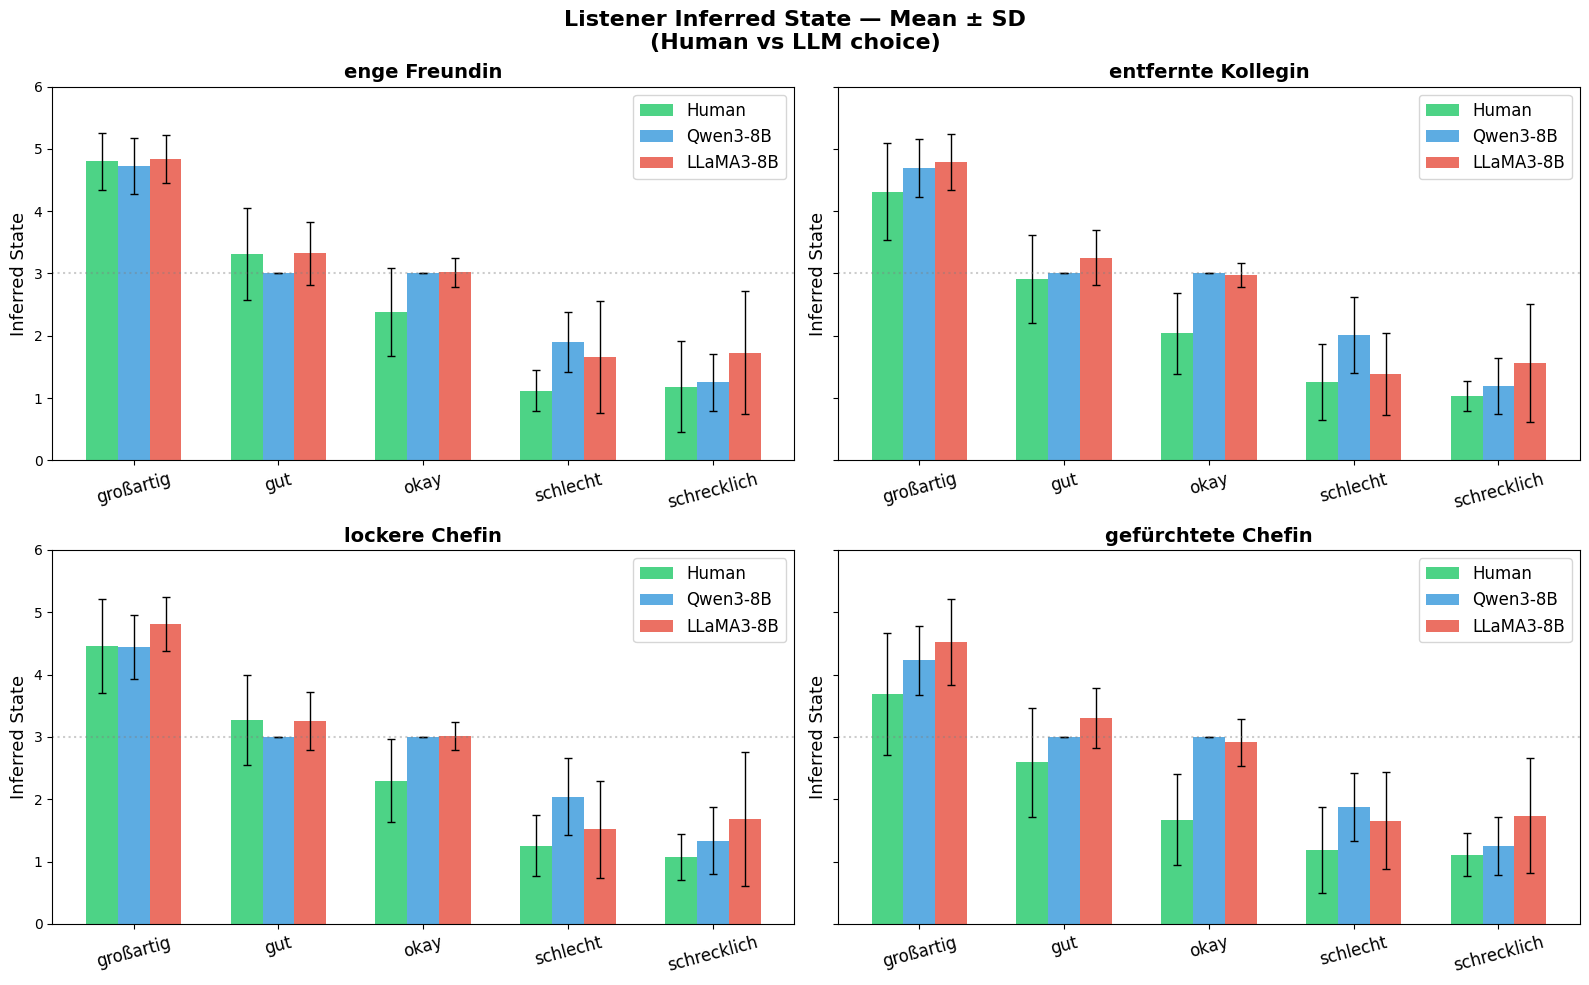

In [24]:
# ── Human Table 3 — Listener inferred state Mean (SD) ────────────────────────
HUMAN_INFERRED = {
    'enge Freundin': {
        'großartig': (4.80, 0.46), 'gut': (3.31, 0.74), 'okay': (2.38, 0.71),
        'schlecht': (1.12, 0.33),  'schrecklich': (1.18, 0.73),
    },
    'entfernte Kollegin': {
        'großartig': (4.31, 0.78), 'gut': (2.91, 0.71), 'okay': (2.04, 0.65),
        'schlecht': (1.26, 0.61),  'schrecklich': (1.04, 0.24),
    },
    'lockere Chefin': {
        'großartig': (4.46, 0.75), 'gut': (3.27, 0.72), 'okay': (2.30, 0.67),
        'schlecht': (1.25, 0.49),  'schrecklich': (1.07, 0.37),
    },
    'gefürchtete Chefin': {
        'großartig': (3.69, 0.98), 'gut': (2.59, 0.87), 'okay': (1.67, 0.73),
        'schlecht': (1.19, 0.69),  'schrecklich': (1.11, 0.35),
    },
}

from pathlib import Path

def load_listener_choice_states(llm_model):
    reviewed = Path(f'results/to_review/listener_choice_{llm_model}.csv')
    raw      = Path(f'results/csv/listener_choice_{llm_model}.csv')
    if reviewed.exists():
        df = pd.read_csv(reviewed)
        df['chosen'] = pd.to_numeric(df['parsed'].replace('', pd.NA), errors='coerce')
        print(f'[수동검토본] {reviewed}  실패: {df["chosen"].isna().sum()}/{len(df)}')
    elif raw.exists():
        df = pd.read_csv(raw)
        df['chosen'] = df['response_text'].apply(_parse_state)
        print(f'[원본CSV] {raw}  실패: {df["chosen"].isna().sum()}/{len(df)}')
    else:
        print(f'[없음] {reviewed}'); return None
    return df.dropna(subset=['chosen'])

# ── Plot ──────────────────────────────────────────────────────────────────────
FONT_TITLE  = 14
FONT_LABEL  = 13
FONT_TICK   = 12
FONT_LEGEND = 12

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()

llm_labels = ['Qwen3-8B', 'LLaMA3-8B']
llm_colors = ['#3498db', '#e74c3c']
x = np.arange(len(UTTERANCES))
width = 0.22

for ax_i, rel in enumerate(RELATIONS):
    ax = axes[ax_i]

    h_means = [HUMAN_INFERRED[rel][adj][0] for adj in UTTERANCES]
    h_sds   = [HUMAN_INFERRED[rel][adj][1] for adj in UTTERANCES]
    ax.bar(x - (len(LLM_MODELS)/2) * width, h_means, width,
           label='Human', color='#2ecc71', alpha=0.85)
    ax.errorbar(x - (len(LLM_MODELS)/2) * width, h_means, h_sds,
                fmt='none', color='black', capsize=3, lw=1)

    for i, llm in enumerate(LLM_MODELS):
        df = load_listener_choice_states(llm)
        if df is None: continue
        offset = x + (i - len(LLM_MODELS)/2 + 1) * width
        m_list, s_list = [], []
        for adj in UTTERANCES:
            mask = (df['relationship'] == rel) & (df['adjective'] == adj)
            vals = df.loc[mask, 'chosen']
            m_list.append(vals.mean() if len(vals) > 0 else np.nan)
            s_list.append(vals.std()  if len(vals) > 1 else 0.0)
        ax.bar(offset, m_list, width, label=llm_labels[i], color=llm_colors[i], alpha=0.8)
        ax.errorbar(offset, m_list, s_list,
                    fmt='none', color='black', capsize=3, lw=1)

    ax.set_title(rel, fontsize=FONT_TITLE, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(UTTERANCES, fontsize=FONT_TICK, rotation=15)
    ax.set_ylabel('Inferred State', fontsize=FONT_LABEL)
    ax.set_ylim(0, 6)
    ax.axhline(3, color='gray', ls=':', alpha=0.4)
    ax.legend(fontsize=FONT_LEGEND)

fig.suptitle('Listener Inferred State — Mean ± SD\n(Human vs LLM choice)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/listener_inferred_state_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000
[수동검토본] results/to_review/listener_choice_llama3-8b_zero.csv  실패: 50/5000
[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000
[수동검토본] results/to_review/listener_choice_llama3-8b_zero.csv  실패: 50/5000
[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000
[수동검토본] results/to_review/listener_choice_llama3-8b_zero.csv  실패: 50/5000
[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000
[수동검토본] results/to_review/listener_choice_llama3-8b_zero.csv  실패: 50/5000


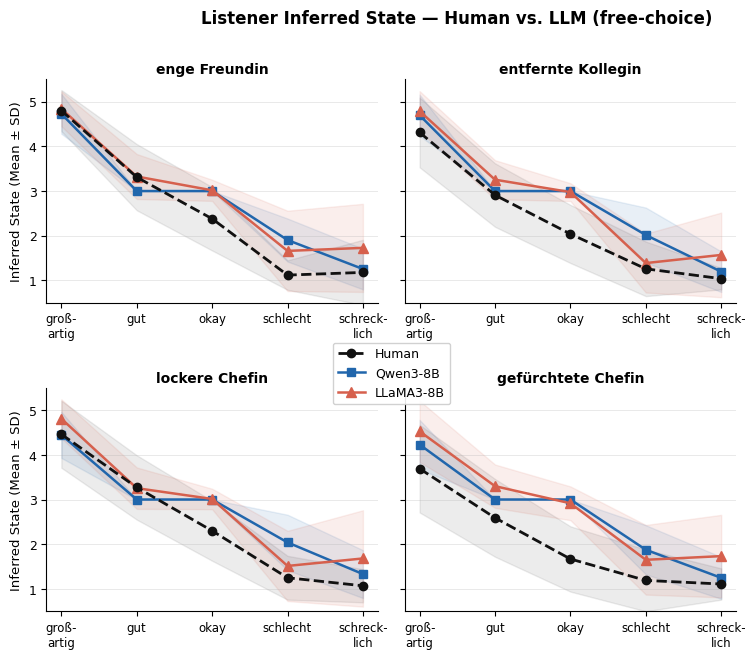

저장 → results/listener_inferred_state_lineplot.pdf / .png


In [44]:
# ── Fig A: Line plot — Listener Inferred State (publication version) ──────────
# Human = black dashed + circle, Qwen3 = blue + square, LLaMA3 = orange + triangle
# Shaded band = ±1 SD; 2×2 subplots (one per relationship)

ADJ_LABELS = ['groß-\nartig', 'gut', 'okay', 'schlecht', 'schreck-\nlich']

STYLE = {
    'Human':     dict(color='#111111', ls='--', marker='o', ms=6,   lw=2.0, zorder=5),
    'Qwen3-8B':  dict(color='#2166ac', ls='-',  marker='s', ms=5.5, lw=1.8, zorder=4),
    'LLaMA3-8B': dict(color='#d6604d', ls='-',  marker='^', ms=6.5, lw=1.8, zorder=4),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
fig.subplots_adjust(hspace=0.38, wspace=0.08,
                    left=0.09, right=0.78, top=0.88, bottom=0.12)

x = np.arange(len(UTTERANCES))

for ax_i, rel in enumerate(RELATIONS):
    ax = axes[ax_i // 2][ax_i % 2]

    # Human
    h_m = np.array([HUMAN_INFERRED[rel][adj][0] for adj in UTTERANCES])
    h_s = np.array([HUMAN_INFERRED[rel][adj][1] for adj in UTTERANCES])
    kw = STYLE['Human']
    ax.plot(x, h_m, label='Human', **kw)
    ax.fill_between(x, h_m - h_s, h_m + h_s, color=kw['color'], alpha=0.08)

    # LLMs
    for llm, label in zip(LLM_MODELS, ['Qwen3-8B', 'LLaMA3-8B']):
        df = load_listener_choice_states(llm)
        if df is None: continue
        m_list, s_list = [], []
        for adj in UTTERANCES:
            vals = df.loc[(df['relationship']==rel) & (df['adjective']==adj), 'chosen']
            m_list.append(vals.mean() if len(vals) > 0 else np.nan)
            s_list.append(vals.std()  if len(vals) > 1 else 0.0)
        m_arr, s_arr = np.array(m_list), np.array(s_list)
        kw = STYLE[label]
        ax.plot(x, m_arr, label=label, **kw)
        ax.fill_between(x, m_arr - s_arr, m_arr + s_arr, color=kw['color'], alpha=0.10)

    ax.set_xticks(x)
    ax.set_xticklabels(ADJ_LABELS, fontsize=8.5)
    ax.set_title(rel, fontsize=10, fontweight='bold', pad=4)
    ax.set_ylim(0.5, 5.5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.tick_params(axis='y', labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', lw=0.4, alpha=0.45, color='#aaaaaa')
    if ax_i % 2 == 0:
        ax.set_ylabel('Inferred State (Mean ± SD)', fontsize=9.5)

handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_,
           loc='center right', bbox_to_anchor=(0.5, 0.46),
           fontsize=9, frameon=True, framealpha=0.9, edgecolor='#cccccc',
           handlelength=2.2)

fig.suptitle('Listener Inferred State — Human vs. LLM (free-choice)',
             fontsize=12, fontweight='bold')

plt.savefig('results/listener_inferred_state_lineplot.pdf', bbox_inches='tight')
plt.savefig('results/listener_inferred_state_lineplot.png', dpi=200, bbox_inches='tight')
plt.show()
print('저장 → results/listener_inferred_state_lineplot.pdf / .png')


[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000
[수동검토본] results/to_review/listener_choice_llama3-8b_zero.csv  실패: 50/5000


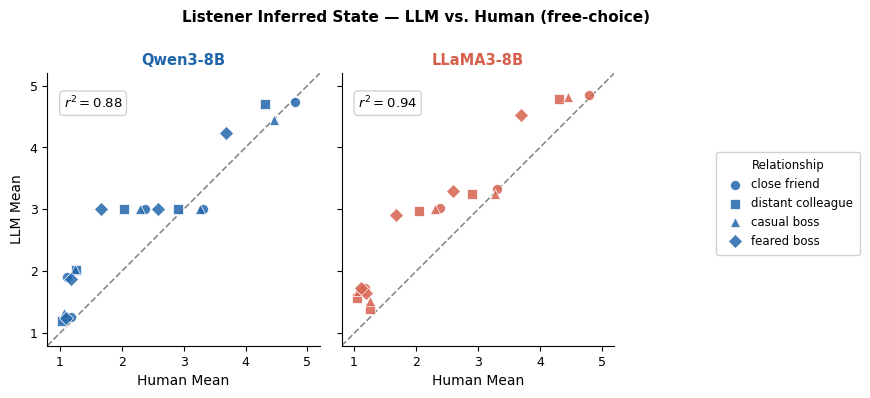

저장 → results/listener_inferred_state_scatter.pdf / .png


In [35]:
# ── Fig B: Scatter plot — LLM mean vs Human mean (publication version) ────────
# Each point = one (relationship × adjective) cell (20 points per model)
# Marker shape = relationship, color = LLM; diagonal = perfect agreement
# R² annotated per panel

from scipy.stats import pearsonr

REL_MARKERS = {'enge Freundin': 'o', 'entfernte Kollegin': 's',
               'lockere Chefin': '^', 'gefürchtete Chefin': 'D'}
REL_SHORT   = {'enge Freundin': 'close friend', 'entfernte Kollegin': 'distant colleague',
               'lockere Chefin': 'casual boss', 'gefürchtete Chefin': 'feared boss'}

LLM_SCATTER = [
    ('qwen3-8b_zero',  'Qwen3-8B',  '#2166ac'),
    ('llama3-8b_zero', 'LLaMA3-8B', '#d6604d'),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharey=True, sharex=True)
fig.subplots_adjust(wspace=0.08, left=0.09, right=0.72, top=0.86, bottom=0.15)

diag = np.linspace(0.8, 5.2, 100)

for ax_i, (llm_key, llm_label, color) in enumerate(LLM_SCATTER):
    ax = axes[ax_i]
    ax.plot(diag, diag, '--', color='#888888', lw=1.2, zorder=1, label='_nolegend_')

    df = load_listener_choice_states(llm_key)
    all_h, all_m = [], []

    for rel, marker in REL_MARKERS.items():
        h_pts, m_pts = [], []
        for adj in UTTERANCES:
            h_mean = HUMAN_INFERRED[rel][adj][0]
            if df is not None:
                vals = df.loc[(df['relationship']==rel) & (df['adjective']==adj), 'chosen']
                llm_mean = vals.mean() if len(vals) > 0 else np.nan
            else:
                llm_mean = np.nan
            h_pts.append(h_mean)
            m_pts.append(llm_mean)

        h_arr = np.array(h_pts)
        m_arr = np.array(m_pts)
        valid = ~np.isnan(m_arr)

        ax.scatter(h_arr[valid], m_arr[valid],
                   marker=marker, color=color, s=52, alpha=0.85,
                   edgecolors='white', linewidths=0.6, zorder=3,
                   label=REL_SHORT[rel])
        all_h.extend(h_arr[valid].tolist())
        all_m.extend(m_arr[valid].tolist())

    # R² annotation
    if len(all_h) > 1:
        r, _ = pearsonr(all_h, all_m)
        r2_val = r ** 2
        ax.text(0.06, 0.92, f'$r^2 = {r2_val:.2f}$',
                transform=ax.transAxes, fontsize=9.5,
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.85))

    ax.set_title(llm_label, fontsize=10.5, fontweight='bold', color=color)
    ax.set_xlabel('Human Mean', fontsize=10)
    ax.set_xlim(0.8, 5.2)
    ax.set_ylim(0.8, 5.2)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.tick_params(labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_aspect('equal')
    if ax_i == 0:
        ax.set_ylabel('LLM Mean', fontsize=10)

# shared legend for relationship shapes (from first panel)
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_,
           loc='center right', bbox_to_anchor=(1.0, 0.52),
           fontsize=8.5, frameon=True, framealpha=0.9,
           edgecolor='#cccccc', title='Relationship', title_fontsize=8.5,
           handletextpad=0.4, borderpad=0.6)

fig.suptitle('Listener Inferred State — LLM vs. Human (free-choice)',
             fontsize=11, fontweight='bold')

plt.savefig('results/listener_inferred_state_scatter.pdf', bbox_inches='tight')
plt.savefig('results/listener_inferred_state_scatter.png', dpi=200, bbox_inches='tight')
plt.show()
print('저장 → results/listener_inferred_state_scatter.pdf / .png')


[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000


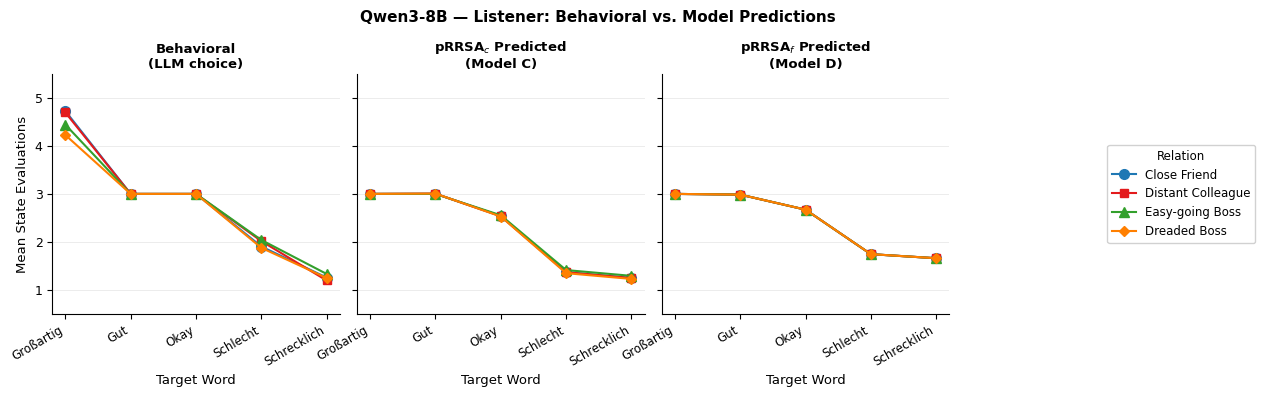

저장 → results/fig1_style_qwen3-8b.pdf / .png
[수동검토본] results/to_review/listener_choice_llama3-8b_zero.csv  실패: 50/5000


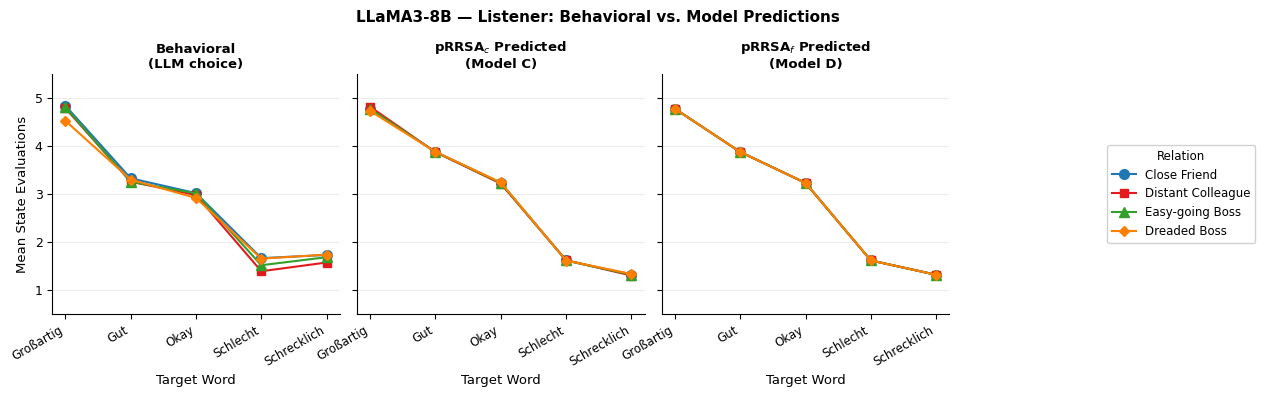

저장 → results/fig1_style_llama3-8b.pdf / .png


In [45]:
# ── Fig C: Behavioral vs. pRRSAc vs. pRRSAf — per LLM (Figure 1 style) ───────
# Layout: 1 figure per LLM, 3 panels side-by-side
#   Panel 1: Behavioral mean (actual LLM choice data)
#   Panel 2: pRRSAc predicted E[state]  (Model C — logit, converged)
#   Panel 3: pRRSAf predicted E[state]  (Model D — logit, converged)
# x-axis: target word, color+marker: relationship

from scipy.special import logsumexp as sp_logsumexp

REL_STYLES = {
    'enge Freundin':      dict(color='#1f78b4', marker='o', ms=7,   lw=1.5, label='Close Friend'),
    'entfernte Kollegin': dict(color='#e31a1c', marker='s', ms=6,   lw=1.5, label='Distant Colleague'),
    'lockere Chefin':     dict(color='#33a02c', marker='^', ms=7,   lw=1.5, label='Easy-going Boss'),
    'gefürchtete Chefin': dict(color='#ff7f00', marker='D', ms=5.5, lw=1.5, label='Dreaded Boss'),
}
ADJ_SHORT = ['Großartig', 'Gut', 'Okay', 'Schlecht', 'Schrecklich']
x = np.arange(len(UTTERANCES))

def _rsa_c_np(phi, alpha, lam):
    phi_b = phi[:, None, None]
    U = phi_b * U_epi[None] + (1 - phi_b) * alpha * U_soc_base[None, :, None]
    s = lam * U
    log_S1 = s - sp_logsumexp(s, axis=1, keepdims=True)
    log_L1 = log_S1 - sp_logsumexp(log_S1, axis=2, keepdims=True)
    return log_L1

def _rsa_f_np(alpha, phi, lam):
    alpha_b = alpha[:, None, None]
    U = phi * U_epi[None] + alpha_b * (1 - phi) * U_soc_base[None, :, None]
    s = lam * U
    log_S1 = s - sp_logsumexp(s, axis=1, keepdims=True)
    log_L1 = log_S1 - sp_logsumexp(log_S1, axis=2, keepdims=True)
    return log_L1

def _pred_mean(log_L1):
    return (np.exp(log_L1) * state_vals[None, None, :]).sum(axis=2)  # (N_rel, N_utt)

def _get_map(tr, param):
    s = tr.posterior[param].values
    if s.ndim == 3:
        return np.array([_kde_mode(s[:,:,r].flatten()) for r in range(N_rel)])
    return _kde_mode(s.flatten())

PANEL_TITLES = [
    'Behavioral\n(LLM choice)',
    'pRRSA$_c$ Predicted\n(Model C)',
    'pRRSA$_f$ Predicted\n(Model D)',
]

for llm_key, llm_label in zip(LLM_MODELS, ['Qwen3-8B', 'LLaMA3-8B']):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), sharey=True)
    fig.subplots_adjust(wspace=0.06, left=0.08, right=0.77, top=0.82, bottom=0.22)

    # ── Panel 1: Behavioral ────────────────────────────────────────────────
    df_ch = load_listener_choice_states(llm_key)
    ax = axes[0]
    if df_ch is not None:
        for rel, sty in REL_STYLES.items():
            means = [df_ch.loc[(df_ch['relationship']==rel) & (df_ch['adjective']==adj), 'chosen'].mean()
                     if len(df_ch.loc[(df_ch['relationship']==rel) & (df_ch['adjective']==adj)]) > 0
                     else np.nan for adj in UTTERANCES]
            ax.plot(x, means, lw=sty['lw'], color=sty['color'],
                    marker=sty['marker'], ms=sty['ms'], label=sty['label'])

    # ── Panel 2: pRRSAc (Model C) ─────────────────────────────────────────
    ax = axes[1]
    tr_c = load_trace(llm_key, 'listener', 'C')
    if tr_c is not None:
        phi_c   = _get_map(tr_c, 'phi')    # (N_rel,)
        alpha_c = _get_map(tr_c, 'alpha')  # scalar
        lam_c   = _get_map(tr_c, 'lam')    # scalar
        pm_c    = _pred_mean(_rsa_c_np(phi_c, alpha_c, lam_c))  # (N_rel, N_utt)
        for r_i, (rel, sty) in enumerate(REL_STYLES.items()):
            ax.plot(x, pm_c[r_i], lw=sty['lw'], color=sty['color'],
                    marker=sty['marker'], ms=sty['ms'], label=sty['label'])

    # ── Panel 3: pRRSAf (Model D) ─────────────────────────────────────────
    ax = axes[2]
    tr_d = load_trace(llm_key, 'listener', 'D')
    if tr_d is not None:
        alpha_d = _get_map(tr_d, 'alpha')  # (N_rel,)
        phi_d   = _get_map(tr_d, 'phi')    # scalar
        lam_d   = _get_map(tr_d, 'lam')    # scalar
        pm_d    = _pred_mean(_rsa_f_np(alpha_d, phi_d, lam_d))
        for r_i, (rel, sty) in enumerate(REL_STYLES.items()):
            ax.plot(x, pm_d[r_i], lw=sty['lw'], color=sty['color'],
                    marker=sty['marker'], ms=sty['ms'], label=sty['label'])

    for ax_i, ax in enumerate(axes):
        ax.set_xticks(x)
        ax.set_xticklabels(ADJ_SHORT, fontsize=8.5, rotation=30, ha='right')
        ax.set_xlabel('Target Word', fontsize=9.5)
        ax.set_ylim(0.5, 5.5)
        ax.set_yticks([1, 2, 3, 4, 5])
        ax.tick_params(axis='y', labelsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', lw=0.4, alpha=0.4, color='#aaaaaa')
        ax.set_title(PANEL_TITLES[ax_i], fontsize=9.5, fontweight='bold', pad=4)
        if ax_i == 0:
            ax.set_ylabel('Mean State Evaluations', fontsize=9.5)

    handles = [plt.Line2D([0],[0], color=sty['color'], lw=sty['lw'],
                          marker=sty['marker'], ms=sty['ms'], label=sty['label'])
               for sty in REL_STYLES.values()]
    fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.01, 0.52),
               fontsize=8.5, frameon=True, framealpha=0.9, edgecolor='#cccccc',
               title='Relation', title_fontsize=8.5)

    fname = llm_key.split('_')[0]
    fig.suptitle(f'{llm_label} — Listener: Behavioral vs. Model Predictions',
                 fontsize=11, fontweight='bold')
    plt.savefig(f'results/fig1_style_{fname}.pdf', bbox_inches='tight')
    plt.savefig(f'results/fig1_style_{fname}.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'저장 → results/fig1_style_{fname}.pdf / .png')


In [47]:
# ── pm_c / pm_d 숫자 출력 (behavioral 포함) ──────────────────────────────────
import pandas as pd

REL_KEYS = list(REL_STYLES.keys())

for llm_key, llm_label in zip(LLM_MODELS, ['Qwen3-8B', 'LLaMA3-8B']):
    print(f'\n{"="*65}')
    print(f'  {llm_label}')
    print(f'{"="*65}')

    # Behavioral
    df_ch = load_listener_choice_states(llm_key)
    if df_ch is not None:
        rows = {}
        for rel in REL_KEYS:
            rows[rel] = [df_ch.loc[(df_ch['relationship']==rel) & (df_ch['adjective']==adj), 'chosen'].mean()
                         for adj in UTTERANCES]
        df_beh = pd.DataFrame(rows, index=ADJ_SHORT).T
        print('\n  [Behavioral]  actual mean state')
        print(df_beh.round(3).to_string())

    for model_name, loader_key in [('Model C (pRRSAc)', 'C'), ('Model D (pRRSAf)', 'D')]:
        tr = load_trace(llm_key, 'listener', loader_key)
        if tr is None:
            print(f'  [{model_name}] trace 없음'); continue

        if loader_key == 'C':
            phi_v   = _get_map(tr, 'phi')
            alpha_v = _get_map(tr, 'alpha')
            lam_v   = _get_map(tr, 'lam')
            pm = _pred_mean(_rsa_c_np(phi_v, alpha_v, lam_v))
        else:
            alpha_v = _get_map(tr, 'alpha')
            phi_v   = _get_map(tr, 'phi')
            lam_v   = _get_map(tr, 'lam')
            pm = _pred_mean(_rsa_f_np(alpha_v, phi_v, lam_v))

        df_pm = pd.DataFrame(pm, index=REL_KEYS, columns=ADJ_SHORT)
        print(f'\n  [{model_name}]  predicted mean state')
        print(df_pm.round(3).to_string())



  Qwen3-8B
[수동검토본] results/to_review/listener_choice_qwen3-8b_zero.csv  실패: 0/5000

  [Behavioral]  actual mean state
                    Großartig  Gut  Okay  Schlecht  Schrecklich
enge Freundin           4.728  3.0   3.0     1.904        1.256
entfernte Kollegin      4.696  3.0   3.0     2.016        1.196
lockere Chefin          4.444  3.0   3.0     2.040        1.332
gefürchtete Chefin      4.228  3.0   3.0     1.876        1.248

  [Model C (pRRSAc)]  predicted mean state
                    Großartig    Gut   Okay  Schlecht  Schrecklich
enge Freundin             3.0  3.004  2.537     1.369        1.248
entfernte Kollegin        3.0  3.004  2.537     1.369        1.248
lockere Chefin            3.0  2.999  2.555     1.413        1.293
gefürchtete Chefin        3.0  3.007  2.529     1.349        1.228

  [Model D (pRRSAf)]  predicted mean state
                    Großartig    Gut   Okay  Schlecht  Schrecklich
enge Freundin             3.0  2.985  2.672     1.745         1.66
entf

In [48]:
# ── Qwen3: scalar alpha (Model C) & scalar phi (Model D) ─────────────────────
import arviz as az

llm_key = 'qwen3-8b_zero'

tr_c = load_trace(llm_key, 'listener', 'C')
tr_d = load_trace(llm_key, 'listener', 'D')

print('=== Model C (pRRSAc): scalar alpha ===')
print(az.summary(tr_c, var_names=['alpha'], kind='stats'))
alpha_c_map = _get_map(tr_c, 'alpha')
print(f'  MAP (KDE mode): alpha_c = {alpha_c_map:.4f}')

print('\n=== Model D (pRRSAf): scalar phi ===')
print(az.summary(tr_d, var_names=['phi'], kind='stats'))
phi_d_map = _get_map(tr_d, 'phi')
print(f'  MAP (KDE mode): phi_d = {phi_d_map:.4f}')

# 실제 비율 계산: phi * U_epi  vs  alpha * (1-phi) * U_soc_base
# Model C: U = phi_r * U_epi + (1-phi_r) * alpha_c * U_soc_base
#   phi_r은 관계별, alpha_c는 공유 스칼라
# Model D: U = phi_d * U_epi + alpha_r * (1-phi_d) * U_soc_base
#   phi_d는 공유 스칼라, alpha_r은 관계별
import numpy as np
phi_c_map = _get_map(tr_c, 'phi')   # shape (N_rel,)
alpha_d_map = _get_map(tr_d, 'alpha')  # shape (N_rel,)

REL_KEYS = list(REL_STYLES.keys())
print('\n=== Model C — informativity vs social weight per relationship ===')
print(f'  alpha_c (shared) = {alpha_c_map:.4f}')
for r_i, rel in enumerate(REL_KEYS):
    phi_r = phi_c_map[r_i]
    soc_weight = (1 - phi_r) * alpha_c_map
    ratio = soc_weight / phi_r if phi_r > 0 else float('inf')
    print(f'  {rel:25s}  phi_r={phi_r:.3f}  soc_weight={(1-phi_r)*alpha_c_map:.3f}  soc/inf={ratio:.2f}x')

print('\n=== Model D — informativity vs social weight per relationship ===')
print(f'  phi_d (shared) = {phi_d_map:.4f}')
for r_i, rel in enumerate(REL_KEYS):
    alpha_r = alpha_d_map[r_i]
    soc_weight = alpha_r * (1 - phi_d_map)
    ratio = soc_weight / phi_d_map if phi_d_map > 0 else float('inf')
    print(f'  {rel:25s}  alpha_r={alpha_r:.3f}  soc_weight={soc_weight:.3f}  soc/inf={ratio:.2f}x')


=== Model C (pRRSAc): scalar alpha ===
        mean     sd  hdi_3%  hdi_97%
alpha  3.838  0.902   2.176      5.0
  MAP (KDE mode): alpha_c = 4.7370

=== Model D (pRRSAf): scalar phi ===
      mean     sd  hdi_3%  hdi_97%
phi  0.081  0.044   0.033    0.166
  MAP (KDE mode): phi_d = 0.0454

=== Model C — informativity vs social weight per relationship ===
  alpha_c (shared) = 4.7370
  enge Freundin              phi_r=0.223  soc_weight=3.683  soc/inf=16.54x
  entfernte Kollegin         phi_r=0.223  soc_weight=3.683  soc/inf=16.54x
  lockere Chefin             phi_r=0.203  soc_weight=3.773  soc/inf=18.54x
  gefürchtete Chefin         phi_r=0.233  soc_weight=3.635  soc/inf=15.63x

=== Model D — informativity vs social weight per relationship ===
  phi_d (shared) = 0.0454
  enge Freundin              alpha_r=3.706  soc_weight=3.537  soc/inf=77.94x
  entfernte Kollegin         alpha_r=4.265  soc_weight=4.072  soc/inf=89.71x
  lockere Chefin             alpha_r=4.403  soc_weight=4.204  soc/inf

In [46]:
# ── Listener R² : predicted E[state] vs observed mean state ───────────────────
from pathlib import Path
from scipy.special import logsumexp as sp_logsumexp

HUMAN_INFERRED = {
    'enge Freundin': {
        'großartig': (4.80, 0.46), 'gut': (3.31, 0.74), 'okay': (2.38, 0.71),
        'schlecht': (1.12, 0.33),  'schrecklich': (1.18, 0.73),
    },
    'entfernte Kollegin': {
        'großartig': (4.31, 0.78), 'gut': (2.91, 0.71), 'okay': (2.04, 0.65),
        'schlecht': (1.26, 0.61),  'schrecklich': (1.04, 0.24),
    },
    'lockere Chefin': {
        'großartig': (4.46, 0.75), 'gut': (3.27, 0.72), 'okay': (2.30, 0.67),
        'schlecht': (1.25, 0.49),  'schrecklich': (1.07, 0.37),
    },
    'gefürchtete Chefin': {
        'großartig': (3.69, 0.98), 'gut': (2.59, 0.87), 'okay': (1.67, 0.73),
        'schlecht': (1.19, 0.69),  'schrecklich': (1.11, 0.35),
    },
}

def rsa_c_np(phi, alpha, lam):
    phi_b = phi[:, None, None]
    U = phi_b * U_epi[None] + (1 - phi_b) * alpha * U_soc_base[None, :, None]
    scaled = lam * U
    log_S1 = scaled - sp_logsumexp(scaled, axis=1, keepdims=True)
    log_L1 = log_S1  - sp_logsumexp(log_S1,  axis=2, keepdims=True)
    return log_L1

def rsa_f_np(alpha, phi, lam):
    alpha_b = alpha[:, None, None]
    U = phi * U_epi[None] + alpha_b * (1 - phi) * U_soc_base[None, :, None]
    scaled = lam * U
    log_S1 = scaled - sp_logsumexp(scaled, axis=1, keepdims=True)
    log_L1 = log_S1  - sp_logsumexp(log_S1,  axis=2, keepdims=True)
    return log_L1

def predicted_state_mean(log_L1):
    return (np.exp(log_L1) * state_vals[None, None, :]).sum(axis=2)

def r2(obs, pred):
    ss_res = ((obs - pred) ** 2).sum()
    ss_tot = ((obs - obs.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

HUMAN_OBS = np.array([
    [HUMAN_INFERRED[rel][adj][0] for adj in UTTERANCES] for rel in RELATIONS
])

def observed_state_mean(llm_model):
    reviewed = Path(f'results/to_review/listener_choice_{llm_model}.csv')
    raw      = Path(f'results/csv/listener_choice_{llm_model}.csv')
    if reviewed.exists():
        df = pd.read_csv(reviewed)
        df['chosen'] = pd.to_numeric(df['parsed'].replace('', pd.NA), errors='coerce')
    elif raw.exists():
        df = pd.read_csv(raw)
        df['chosen'] = df['response_text'].apply(_parse_state)
    else:
        return None
    df = df.dropna(subset=['chosen'])
    mat = np.full((N_rel, N_utt), np.nan)
    for r_i, rel in enumerate(RELATIONS):
        for u_i, adj in enumerate(UTTERANCES):
            vals = df.loc[(df['relationship']==rel)&(df['adjective']==adj), 'chosen']
            if len(vals): mat[r_i, u_i] = vals.mean()
    return mat

# ── MODEL_FN: MAP point estimate 사용 (Human MAP과 일관성) ──────────────────────
def _map_phi(tr):
    s = tr.posterior['phi'].values
    return np.array([_kde_mode(s[:,:,r].flatten()) for r in range(N_rel)])

def _map_alpha_vec(tr):
    s = tr.posterior['alpha'].values
    return np.array([_kde_mode(s[:,:,r].flatten()) for r in range(N_rel)])

def _map_scalar(tr, param):
    return _kde_mode(tr.posterior[param].values.flatten())

MODEL_FN = {
    'A': lambda tr: rsa_c_np(_map_phi(tr),
                              _map_scalar(tr, 'alpha'),
                              _map_scalar(tr, 'lam')),
    'B': lambda tr: rsa_f_np(_map_alpha_vec(tr),
                              _map_scalar(tr, 'phi'),
                              _map_scalar(tr, 'lam')),
    'C': lambda tr: rsa_c_np(_map_phi(tr),
                              _map_scalar(tr, 'alpha'),
                              _map_scalar(tr, 'lam')),
    'D': lambda tr: rsa_f_np(_map_alpha_vec(tr),
                              _map_scalar(tr, 'phi'),
                              _map_scalar(tr, 'lam')),
}

rows = []
for llm in LLM_MODELS:
    obs = observed_state_mean(llm)
    if obs is None: continue
    short = 'Qwen3' if 'qwen' in llm else 'LLaMA3'

    for mid, fn in MODEL_FN.items():
        tr = load_trace(llm, 'listener', mid)
        if tr is None: continue
        pred = predicted_state_mean(fn(tr))

        row = {'LLM': short, 'Model': mid,
               'R²_vs_LLM': round(r2(obs.flatten(), pred.flatten()), 3),
               'R²_vs_Human': round(r2(HUMAN_OBS.flatten(), pred.flatten()), 3)}
        for r_i, rel in enumerate(RELATIONS):
            row[f'R²_LLM_{rel[:4]}'] = round(r2(obs[r_i], pred[r_i]), 3)
            row[f'R²_Hum_{rel[:4]}'] = round(r2(HUMAN_OBS[r_i], pred[r_i]), 3)
        rows.append(row)

df_r2 = pd.DataFrame(rows)
print(df_r2.to_string(index=False))
df_r2.to_csv('results/listener_r2.csv', index=False)
print('\n저장 → results/listener_r2.csv')


   LLM Model  R²_vs_LLM  R²_vs_Human  R²_LLM_enge  R²_Hum_enge  R²_LLM_entf  R²_Hum_entf  R²_LLM_lock  R²_Hum_lock  R²_LLM_gefü  R²_Hum_gefü
 Qwen3     A      0.590        0.333        0.600        0.503        0.563        0.300        0.558        0.397        0.643       -0.177
 Qwen3     B      0.224        0.049        0.213        0.154        0.214        0.018        0.237        0.129        0.230       -0.405
 Qwen3     C      0.527        0.696        0.501        0.643        0.488        0.716        0.514        0.710        0.621        0.700
 Qwen3     D      0.565        0.605        0.530        0.578        0.523        0.617        0.567        0.636        0.660        0.527
LLaMA3     A      0.917        0.638        0.921        0.848        0.924        0.612        0.917        0.807        0.905       -0.091
LLaMA3     B      0.520        0.639        0.464        0.602        0.552        0.653        0.510        0.666        0.554        0.587
LLaMA3     C 

---
## Hierarchy Recovery

In [29]:
# ── Kendall's τ — hierarchy recovery ─────────────────────────────────────────
from scipy.stats import kendalltau

HUMAN_PHI_MAP   = np.array([HUMAN_PHI[r]   for r in RELATIONS])
HUMAN_ALPHA_MAP = np.array([HUMAN_ALPHA[r] for r in RELATIONS])

rows = []
for llm in LLM_MODELS:
    short = 'Qwen3' if 'qwen' in llm else 'LLaMA3'
    for role in ['listener', 'speaker']:
        for mid in ['A', 'B', 'C', 'D']:
            tr = load_trace(llm, role, mid)
            if tr is None: continue

            if mid in ('A', 'C'):
                param = 'phi'
                human_ref = HUMAN_PHI_MAP
            else:
                param = 'alpha'
                human_ref = HUMAN_ALPHA_MAP

            if param not in tr.posterior: continue
            samp = tr.posterior[param].values   # (chain, draw, rel)
            llm_map = np.array([_kde_mode(samp[:, :, r_i].flatten()) for r_i in range(N_rel)])

            tau, pval = kendalltau(human_ref, llm_map)
            rows.append({'LLM': short, 'Role': role, 'Model': mid,
                         'param': param,
                         'tau': round(tau, 3), 'p': round(pval, 4)})

df_tau = pd.DataFrame(rows)
print(df_tau.to_string(index=False))
df_tau.to_csv('results/hierarchy_kendall_tau.csv', index=False)
print('\n저장 → results/hierarchy_kendall_tau.csv')

   LLM     Role Model param    tau      p
 Qwen3 listener     A   phi -0.333 0.7500
 Qwen3 listener     B alpha  0.333 0.7500
 Qwen3 listener     C   phi -0.667 0.3333
 Qwen3 listener     D alpha  0.000 1.0000
 Qwen3  speaker     A   phi -0.667 0.3333
 Qwen3  speaker     B alpha -0.667 0.3333
 Qwen3  speaker     C   phi  0.000 1.0000
 Qwen3  speaker     D alpha -0.333 0.7500
LLaMA3 listener     A   phi  0.000 1.0000
LLaMA3 listener     B alpha  0.000 1.0000
LLaMA3 listener     C   phi  0.000 1.0000
LLaMA3 listener     D alpha  1.000 0.0833
LLaMA3  speaker     A   phi -0.333 0.7500
LLaMA3  speaker     B alpha -0.333 0.7500
LLaMA3  speaker     C   phi -0.333 0.7500
LLaMA3  speaker     D alpha -0.333 0.7500

저장 → results/hierarchy_kendall_tau.csv


In [30]:
# ── Discrimination range — predicted E[state] max-min per relationship ────────
# 얼마나 adjective 간 state 추론을 잘 구분하는지 (range = max - min over utterances)
# Human reference도 함께 출력

HUMAN_RANGE = {rel: max(v[0] for v in HUMAN_INFERRED[rel].values())
                    - min(v[0] for v in HUMAN_INFERRED[rel].values())
               for rel in RELATIONS}

rows = []
for llm in LLM_MODELS:
    short = 'Qwen3' if 'qwen' in llm else 'LLaMA3'
    for mid, fn in MODEL_FN.items():
        tr = load_trace(llm, 'listener', mid)
        if tr is None: continue
        pred = predicted_state_mean(fn(tr))   # (N_rel, N_utt)
        for r_i, rel in enumerate(RELATIONS):
            disc = float(pred[r_i].max() - pred[r_i].min())
            rows.append({'LLM': short, 'Model': mid, 'Relationship': rel,
                         'disc_range': round(disc, 3),
                         'human_range': round(HUMAN_RANGE[rel], 2)})

df_disc = pd.DataFrame(rows)
pivot = df_disc.pivot_table(index=['LLM','Model'], columns='Relationship',
                            values='disc_range', aggfunc='first')
human_row = pd.DataFrame([HUMAN_RANGE], index=pd.MultiIndex.from_tuples([('Human','MAP')],
                          names=['LLM','Model']))
print(pd.concat([human_row, pivot]).to_string())
df_disc.to_csv('results/discrimination_range.csv', index=False)
print('\n저장 → results/discrimination_range.csv')

              enge Freundin  entfernte Kollegin  lockere Chefin  gefürchtete Chefin
LLM    Model                                                                       
Human  MAP            3.680               3.270           3.390               2.580
LLaMA3 A              3.191               3.273           3.223               3.057
       B              1.458               1.458           1.458               1.458
       C              3.455               3.517           3.457               3.396
       D              3.460               3.460           3.460               3.460
Qwen3  A              1.287               1.187           1.052               1.304
       B              0.354               0.356           0.353               0.353
       C              1.756               1.756           1.707               1.779
       D              1.340               1.340           1.340               1.340

저장 → results/discrimination_range.csv


---
## 5.5 Cross-task Consistency

In [31]:
# ── Cross-task consistency — listener vs speaker parameter comparison ──────────
# param_hdi_95.csv 재활용 (이미 저장됨)
df_hdi = pd.read_csv('results/param_hdi_95.csv')

rows = []
for llm in ['Qwen3', 'LLaMA3']:
    for mid in ['A', 'B', 'C', 'D']:
        param  = 'phi'   if mid in ('A','C') else 'alpha'
        model  = f'pRRSAc({mid})' if mid in ('A','C') else f'pRRSAf({mid})'
        for rel in RELATIONS:
            mask = (df_hdi['llm'] == llm) & (df_hdi['model'] == model) & \
                   (df_hdi['relationship'] == rel) & (df_hdi['param'] == param)
            li = df_hdi[mask & (df_hdi['role'] == 'listener')]
            sp = df_hdi[mask & (df_hdi['role'] == 'speaker')]
            if li.empty or sp.empty: continue
            li_m, li_lo, li_hi = li[['mean','hdi_low','hdi_high']].values[0]
            sp_m, sp_lo, sp_hi = sp[['mean','hdi_low','hdi_high']].values[0]
            # HDI overlap check: consistent if listener HDI ∩ speaker HDI ≠ ∅
            overlap = max(0, min(li_hi, sp_hi) - max(li_lo, sp_lo))
            rows.append({
                'LLM': llm, 'Model': mid, 'param': param, 'Relationship': rel,
                'LI_mean': li_m, 'LI_hdi': f'[{li_lo}, {li_hi}]',
                'SP_mean': sp_m, 'SP_hdi': f'[{sp_lo}, {sp_hi}]',
                'HDI_overlap': round(overlap, 3),
                'consistent': '✓' if overlap > 0 else '✗',
            })

df_cross = pd.DataFrame(rows)
print(df_cross[['LLM','Model','Relationship','LI_mean','SP_mean',
                'HDI_overlap','consistent']].to_string(index=False))
df_cross.to_csv('results/cross_task_consistency.csv', index=False)
print('\n저장 → results/cross_task_consistency.csv')

   LLM Model       Relationship  LI_mean  SP_mean  HDI_overlap consistent
 Qwen3     A      enge Freundin    0.499    0.531        0.521          ✓
 Qwen3     A entfernte Kollegin    0.412    0.545        0.516          ✓
 Qwen3     A     lockere Chefin    0.346    0.678        0.270          ✓
 Qwen3     A gefürchtete Chefin    0.370    0.688        0.309          ✓
 Qwen3     B      enge Freundin    2.738    3.720        3.054          ✓
 Qwen3     B entfernte Kollegin    2.612    3.684        3.093          ✓
 Qwen3     B     lockere Chefin    2.644    2.600        2.552          ✓
 Qwen3     B gefürchtete Chefin    3.023    0.994        0.685          ✓
 Qwen3     C      enge Freundin    0.207    0.835        0.000          ✗
 Qwen3     C entfernte Kollegin    0.208    0.822        0.000          ✗
 Qwen3     C     lockere Chefin    0.205    0.868        0.000          ✗
 Qwen3     C gefürchtete Chefin    0.210    0.848        0.000          ✗
 Qwen3     D      enge Freundin    2.8

---
## MAP vs Mean 비교 (posterior symmetry 확인)

In [32]:
# ── MAP (KDE mode) vs posterior mean 비교 ────────────────────────────────────
# MAP = KDE의 최댓값 위치 (argmax of kernel density estimate over fine grid)
from scipy.stats import gaussian_kde
from scipy.stats import skew as scipy_skew

def kde_mode(samples, n_grid=2000):
    """KDE로 추정한 posterior mode (MAP proxy)"""
    lo, hi = samples.min(), samples.max()
    grid = np.linspace(lo, hi, n_grid)
    kde = gaussian_kde(samples, bw_method='scott')
    return float(grid[kde(grid).argmax()])

rows = []
for llm in LLM_MODELS:
    short = 'Qwen3' if 'qwen' in llm else 'LLaMA3'
    for role in ['listener', 'speaker']:
        for mid in ['A', 'B', 'C', 'D']:
            tr = load_trace(llm, role, mid)
            if tr is None: continue
            param = 'phi' if mid in ('A','C') else 'alpha'
            if param not in tr.posterior: continue
            samples_arr = tr.posterior[param].values  # (chain, draw) or (chain, draw, rel)

            if samples_arr.ndim == 3:
                # per-relationship param
                for r_i, rel in enumerate(RELATIONS):
                    flat = samples_arr[:, :, r_i].flatten()
                    mean = float(flat.mean())
                    mode = kde_mode(flat)
                    sk   = float(scipy_skew(flat))
                    rows.append({'LLM': short, 'Role': role, 'Model': mid,
                                 'param': param, 'Relationship': rel,
                                 'mean': round(mean, 3), 'MAP(KDE)': round(mode, 3),
                                 'diff': round(abs(mean - mode), 3),
                                 'skewness': round(sk, 3)})
            else:
                # global param (scalar)
                flat = samples_arr.flatten()
                mean = float(flat.mean())
                mode = kde_mode(flat)
                sk   = float(scipy_skew(flat))
                rows.append({'LLM': short, 'Role': role, 'Model': mid,
                             'param': param, 'Relationship': 'global',
                             'mean': round(mean, 3), 'MAP(KDE)': round(mode, 3),
                             'diff': round(abs(mean - mode), 3),
                             'skewness': round(sk, 3)})

df_map = pd.DataFrame(rows)
# diff > 0.05 인 케이스 강조
flagged = df_map[df_map['diff'] > 0.05]
print(f'전체 {len(df_map)}개 중 diff > 0.05: {len(flagged)}개\n')
print(df_map.to_string(index=False))
df_map.to_csv('results/map_vs_mean.csv', index=False)
print(f'\n저장 → results/map_vs_mean.csv')
if len(flagged):
    print('\n[주의] Mean-MAP 차이 > 0.05 케이스:')
    print(flagged[['LLM','Role','Model','param','Relationship','mean','MAP(KDE)','diff','skewness']].to_string(index=False))

전체 64개 중 diff > 0.05: 50개

   LLM     Role Model param       Relationship  mean  MAP(KDE)  diff  skewness
 Qwen3 listener     A   phi      enge Freundin 0.499     0.149 0.349     0.134
 Qwen3 listener     A   phi entfernte Kollegin 0.412     0.137 0.275     0.166
 Qwen3 listener     A   phi     lockere Chefin 0.346     0.121 0.225     0.164
 Qwen3 listener     A   phi gefürchtete Chefin 0.370     0.151 0.219     0.155
 Qwen3 listener     B alpha      enge Freundin 2.738     3.239 0.501    -0.100
 Qwen3 listener     B alpha entfernte Kollegin 2.612     1.694 0.918    -0.079
 Qwen3 listener     B alpha     lockere Chefin 2.644     3.591 0.947    -0.127
 Qwen3 listener     B alpha gefürchtete Chefin 3.023     4.295 1.272    -0.219
 Qwen3 listener     C   phi      enge Freundin 0.207     0.223 0.016     0.104
 Qwen3 listener     C   phi entfernte Kollegin 0.208     0.223 0.014     0.089
 Qwen3 listener     C   phi     lockere Chefin 0.205     0.203 0.001     0.089
 Qwen3 listener     C   p

In [14]:
import arviz as az

for llm in ['qwen3-8b_zero', 'llama3-8b_zero']:
    for task in ['speaker', 'listener']:
        for cfg in ['C', 'D']:
            tr = load_trace(llm, task, cfg)
            if tr is not None:
                s = az.summary(tr, var_names=['c', 'sigma'])
                print(f'\n=== {llm} {task} {cfg} ===')
                print(s)


=== qwen3-8b_zero speaker C ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
c     -4.535  0.337  -5.161   -3.892      0.003    0.002    9608.0    9048.0   
sigma  5.135  0.154   4.847    5.423      0.002    0.001    9079.0    8342.0   

       r_hat  
c        1.0  
sigma    1.0  

=== qwen3-8b_zero speaker D ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
c     -4.509  0.338  -5.113   -3.838      0.003    0.002   11824.0   11372.0   
sigma  5.128  0.155   4.844    5.425      0.001    0.001   15770.0   11041.0   

       r_hat  
c        1.0  
sigma    1.0  

=== qwen3-8b_zero listener C ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
c     -1.983  0.117  -2.206   -1.766      0.001    0.001    8966.0    8089.0   
sigma  2.168  0.068   2.044    2.297      0.001    0.000    9544.0    8756.0   

       r_hat  
c        1.0  
sigma    1.0  

=== qwen3-8b_zero listener D ===
        